## **Topic 2**

### Intro to AI and Data Science

- **AI**
    - Technology to simulate human intelligence
    1. Acting Humanly
    2. Thinking Humanly
    3. Acting Rationally
    4. Thinking Rationally

- **Data Science**
    - Extract meaningful insights from data for decision making 
    1. Big Data - Enormous Complex Data
    2. Data driven decision making
        - Reduce Risks
        - Cost Savings

- **Application**: *AI for Human Resource Management*
    1. Talent Acquisition (TA)
    2. Learning and Training Programs
    3. Internal Employee Management
    4. Onboarding of new recruits

### Data Wrangling

`Data Munging`, `Data Remediation`
- Clean, transform and prepare raw data into format suited for analysis
- To ensure reliability and completeness of dataset
- Enhance accuracy and value of insights from data

**Six Steps of Data Wrangling**
| **Step**       | **Description**                                                                 |
|----------------|----------------------------------------------------------------------------------|
| **1. Discovery**   | Identify data sources, assess data quality, and understand data format/structure.     |
| **2. Structuring** | Reshape, convert, and fill missing data to ensure a standardized data presentation.  |
| **3. Cleaning**    | Handle inaccuracies, remove duplicates, and fix anomalies for error-free data.        |
| **4. Enriching**   | Merge with external sources and augment data for deeper comprehension.               |
| **5. Validation**  | Ensure data meets quality and integrity standards required for analysis.             |
| **6. Publishing**  | Document the entire process and prepare data for storage or integration.             |

**Titanic Dataset Use Case**

In [327]:
import pandas as pd
import requests
from pathlib import Path

datapath = Path('Data')
datapath.mkdir(parents=True, exist_ok=True)
filepath = datapath / 'titanic_train.csv'

response = requests.get("https://raw.githubusercontent.com/prof-sushil/Data-Science-World/refs/heads/main/data/titanic_train.csv")
with open(filepath, "wb") as f:
    f.write(response.content)

print(f"File saved to {filepath}")

File saved to Data\titanic_train.csv


In [328]:
# Working with the dataset
df = pd.read_csv("Data/titanic_train.csv")
df.head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


In [329]:
df.shape # Rows (Datapoints), Columns

(891, 12)

In [330]:
df.describe() # Statistical Description

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [331]:
df.info() # Summary

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [332]:
# Inspecting the data
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [333]:
df.duplicated().sum() # No duplicates

np.int64(0)

In [334]:
# Checking an important column
df["Survived"].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

**Handling Missing Values**
- Impute (Predictive Models, Group Stats, Mean , Median, Mode)
- Drop missing (If number is large)

In [335]:
df["Cabin"].isnull().sum() # Large number of missing

np.int64(687)

In [336]:
df["Age"].isnull().sum() # Fairly low

np.int64(177)

In [337]:
df["Embarked"].isnull().sum() # Negligible

np.int64(2)

In [338]:
# Drop Cabin
df = df.drop("Cabin", axis=1)

# Mean Imputation for Age
mean_age = df["Age"].mean()
df["Age"] = df["Age"].fillna(mean_age)

# Mode Imputation for Embarked
mode_embarked = df["Embarked"].mode()[0]
df["Embarked"] = df["Embarked"].fillna(mode_embarked)

# Checking after handling all missing values
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

**Feature types:**

1. Categorical
    - Nominal: Unordered, no quantitative values\
        - Example: (RGB), (Male, Female)
    - Ordinal: Ordered, Ranked
        - Example: (Poor, Fair, Good), (Unsatisfied, Neutral, Satisfied)

2. Numeric
    - Discrete: Integer 
    - Continuous: Float

**Encoding Categorical Values**

- Convert to Numerical Format  
  - **Label Encoding**: Ordinal  
    - Assign unique integer to each category  
      - Example: (Bad, Neutral, Good) ➡️ (0, 1, 2)  

  - **One Hot Encoding**: Nominal  
    - Column representation of presence and absence  
      - Example: [Red, Yellow, Green] ➡️ [1, 0, 0]  

    - OHE Drawback  
      - Increased dimensionality  
      - Computational inefficiency  

    - Solution is **Frequency Encoding**

In [339]:
columns = df.columns
columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked'],
      dtype='object')

In [340]:
categorical = df.dtypes[df.dtypes == "object"].index
categorical

Index(['Name', 'Sex', 'Ticket', 'Embarked'], dtype='object')

In [341]:
numerical = df.dtypes[df.dtypes == "int"].index
numerical

Index(['PassengerId', 'Survived', 'Pclass', 'SibSp', 'Parch'], dtype='object')

In [342]:
# Unique Categorical
for cat in categorical:
    print(f"Number of unique values in {cat}: {len(df[cat].unique())}")

Number of unique values in Name: 891
Number of unique values in Sex: 2
Number of unique values in Ticket: 681
Number of unique values in Embarked: 3


In [343]:
"""
Using One Hot Encoding on Name, Ticket isn't efficient 
But we can apply OHE on Sex, Embarked
"""
df_SeEmb = df[["Sex", "Embarked"]]
df_SeEmb

,Sex,Embarked
0,male,S
1,female,C
2,female,S
3,female,S
4,male,S
...,...,...
886,male,S
887,female,S
888,female,S
889,male,C


In [344]:
df_SeEmb_encoded = pd.get_dummies(df_SeEmb) # Add. Args `columns`, `drop_first`
df_SeEmb_encoded

"""
`drop_first`: Keeps all info, uses fewer columns
"""

'\n`drop_first`: Keeps all info, uses fewer columns\n'

In [345]:
df_SeEmb_encoded.shape

(891, 5)

In [346]:
# Using SkLearn for Label Encoding
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
df_copy = df.copy()

df_copy["Embarked"] = label_encoder.fit_transform(df_copy["Embarked"])

df_copy.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.000000,0,0,211536,13.00,2
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.000000,0,0,112053,30.00,2
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,29.699118,1,2,W./C. 6607,23.45,2
889,890,1,1,"Behr, Mr. Karl Howell",male,26.000000,0,0,111369,30.00,0
890,891,0,3,"Dooley, Mr. Patrick",male,32.000000,0,0,370376,7.75,1


In [347]:
# Saving the cleaned dataset
df_SeEmb_encoded.to_csv("Data/cleaned_SeEmb.csv", index=False)

### Data Visualization

**Matplotlib** 
- Visualization library for Python

In [348]:
import matplotlib
import matplotlib.pyplot as plt

print(f"Matplotlib Version: {matplotlib.__version__}")

Matplotlib Version: 3.9.4


[]

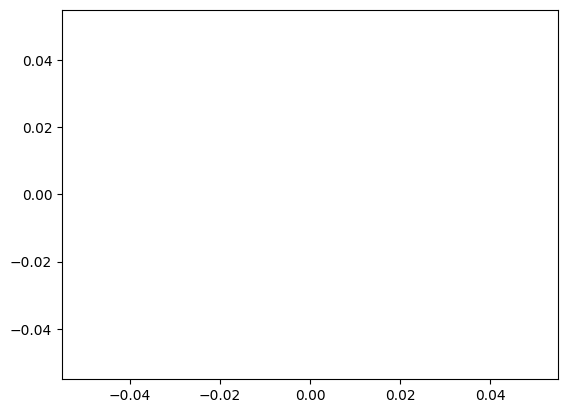

In [349]:
# Simple Plotting
plt.plot()

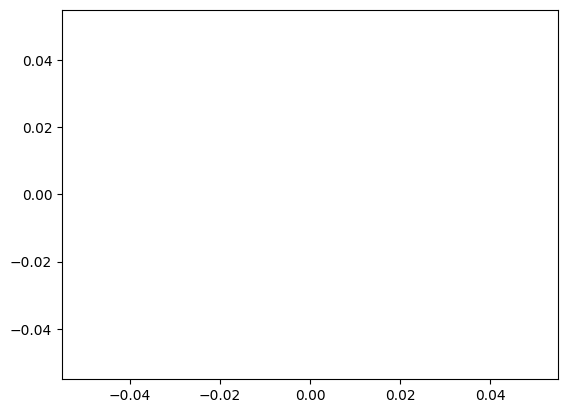

In [350]:
plt.plot();

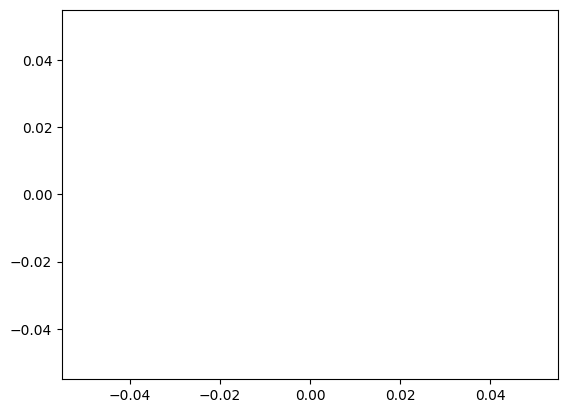

In [351]:
plt.plot() # Same as using plt.plot();
plt.show()

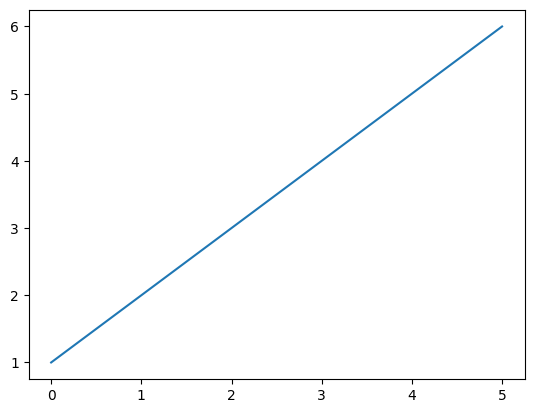

In [352]:
plt.plot([1,2,3,4,5,6])

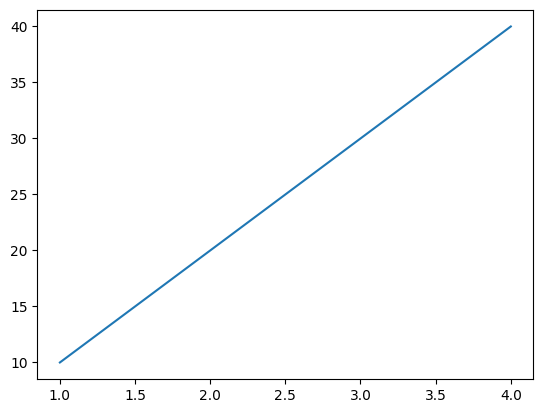

In [353]:
# Using custom data (x, y)
x = [1,2,3,4] 
y = [10,20,30,40]

plt.plot(x, y)

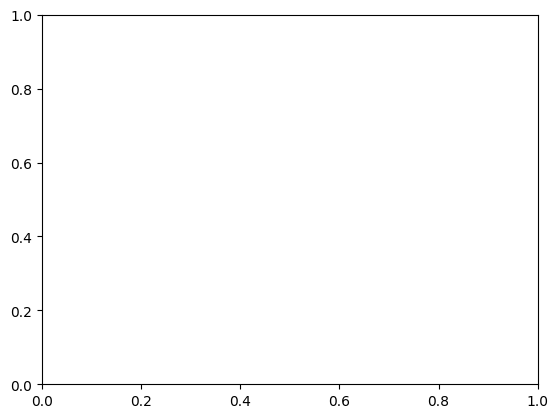

In [354]:
# Object Oriented Version
fig = plt.figure() # Create Figure
ax = fig.add_subplot() # Add an axes
plt.show()

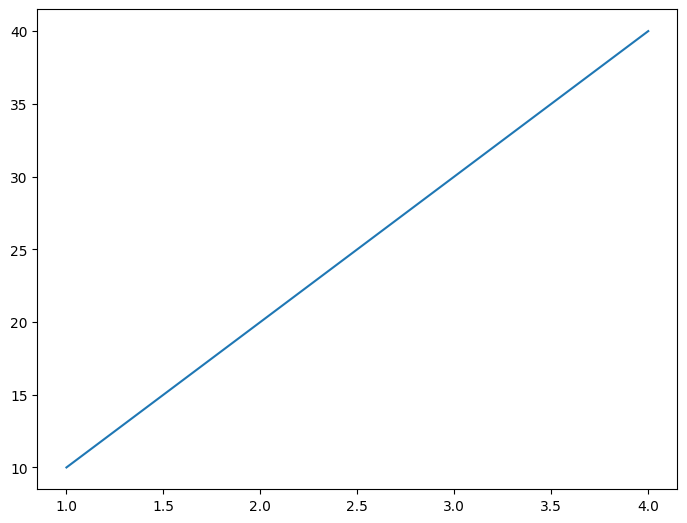

In [355]:
fig = plt.figure()
ax = fig.add_axes([1,1,1,1]) # left, bottom, width, height
ax.plot(x, y)
plt.show()

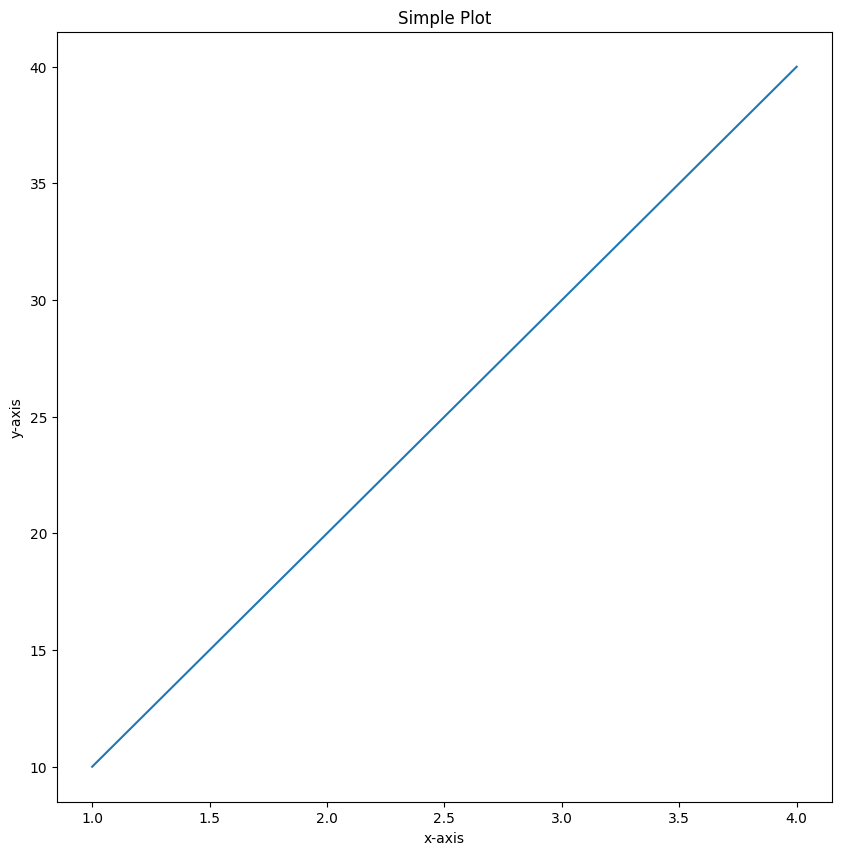

In [356]:
fig, ax = plt.subplots(figsize=(10,10))
ax.set(title="Simple Plot", xlabel="x-axis", ylabel="y-axis")
ax.plot(x, y);

fig.savefig("Data/simpleplot.png")

In [357]:
type(fig), type(ax)

(matplotlib.figure.Figure, matplotlib.axes._axes.Axes)

In [358]:
# Matplotlib visualizations built on NumPy Arrays
#   Line, Scatter, Bar, Histogram Plots

import numpy as np
x = np.linspace(0, 10, 100)
x[:10]

array([0.        , 0.1010101 , 0.2020202 , 0.3030303 , 0.4040404 ,
       0.50505051, 0.60606061, 0.70707071, 0.80808081, 0.90909091])

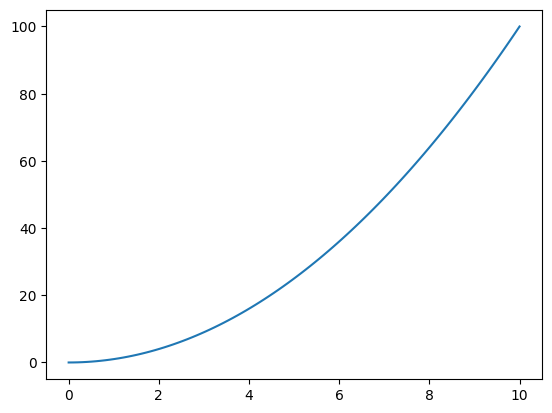

In [359]:
fig, ax = plt.subplots()
ax.plot(x, x**2); # (x, y), Quadratic

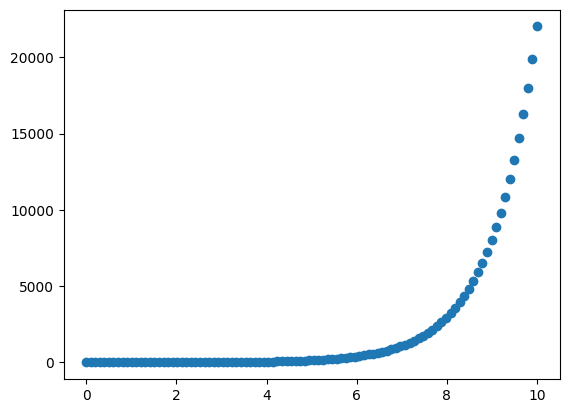

In [360]:
fig, ax = plt.subplots()
ax.scatter(x, np.exp(x));

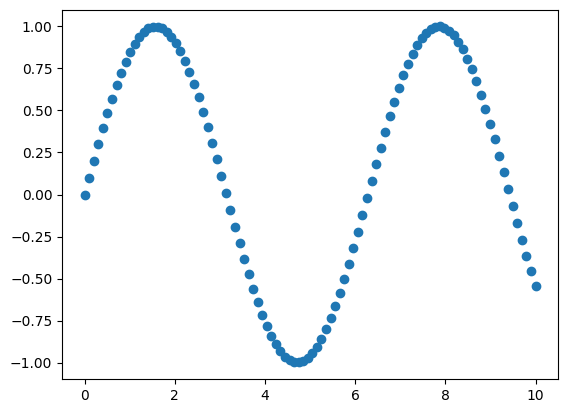

In [361]:
fig, ax = plt.subplots()
ax.scatter(x, np.sin(x));

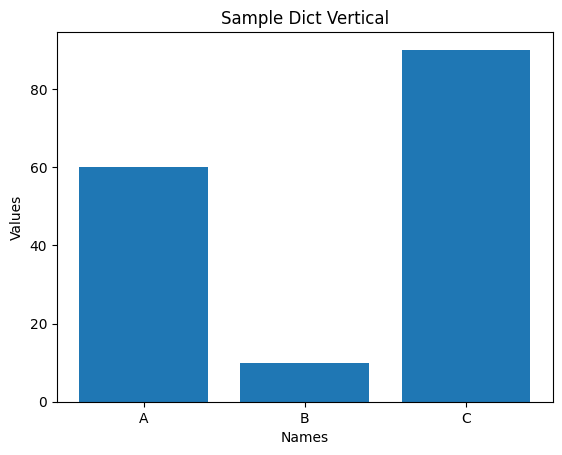

In [362]:
# Bar Plots
#   ax.bar() for Vertical
#   ax.barh() for Horizontal

sample_dict = {"A": 60,
               "B": 10,
               "C": 90}

fig, ax = plt.subplots()
ax.bar(sample_dict.keys(), sample_dict.values())
ax.set(title="Sample Dict Vertical", xlabel="Names", ylabel="Values");

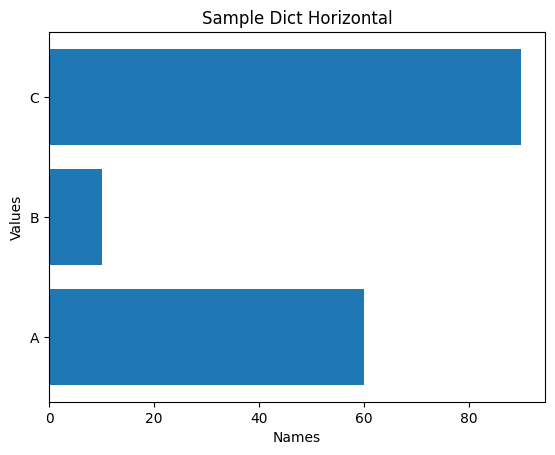

In [363]:
fig, ax = plt.subplots()
ax.barh(sample_dict.keys(), sample_dict.values())
ax.set(title="Sample Dict Horizontal", xlabel="Names", ylabel="Values");

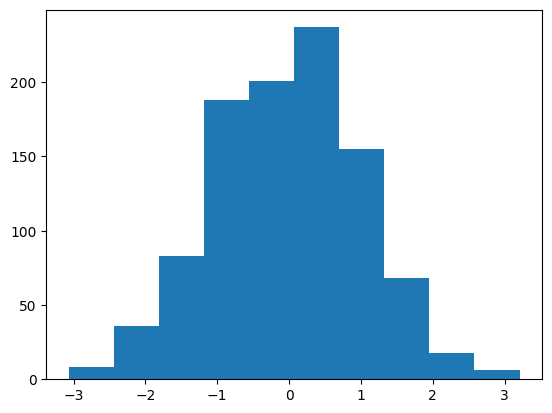

In [364]:
# Histogram: Distribution over a large range
x = np.random.randn(1000) # `randn` Normal, `random` Random

fig, ax = plt.subplots()
ax.hist(x);

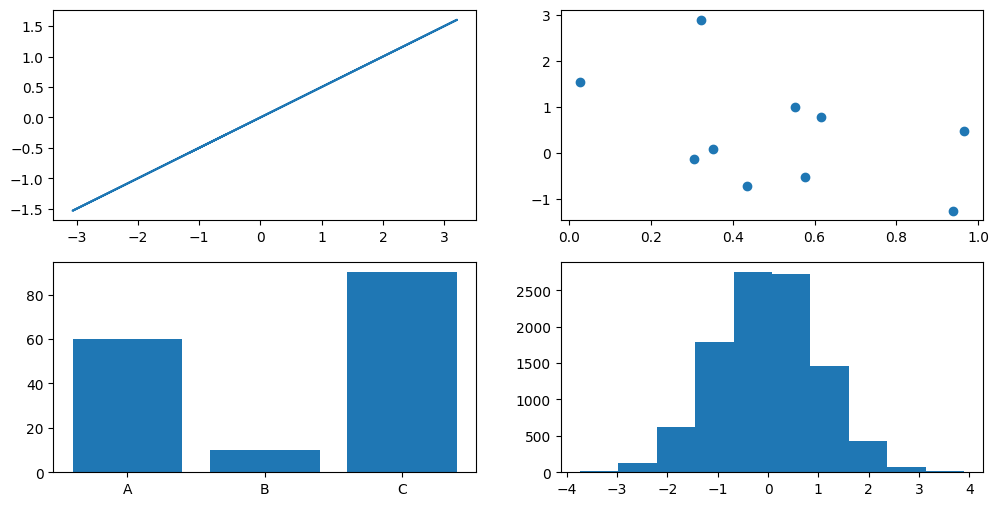

In [365]:
# Subplots
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(nrows=2,
                                             ncols=2,
                                             figsize=(12,6))

ax1.plot(x, x/2);
ax2.scatter(np.random.random(10), np.random.randn(10));
ax3.bar(sample_dict.keys(), sample_dict.values());
ax4.hist(np.random.randn(10000));

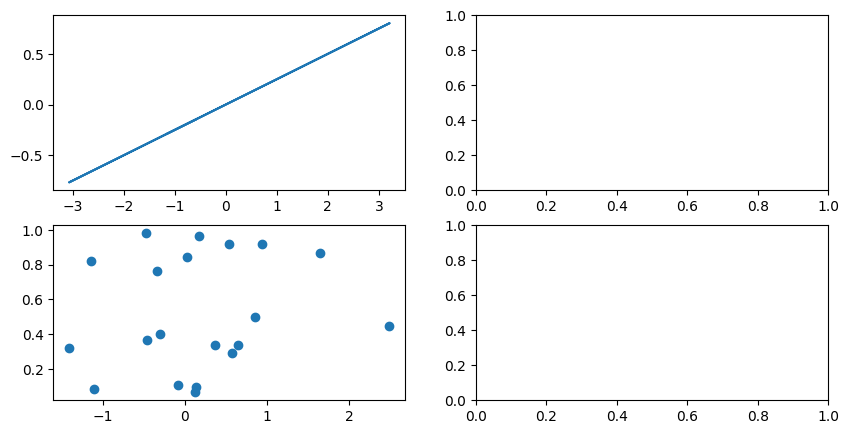

In [366]:
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(10,5)) # 2*2 Matrix
ax[0,0].plot(x, x/4);
ax[1,0].scatter(np.random.randn(20), np.random.random(20));

In [367]:
# Plot directly with Pandas
ts = pd.Series(np.random.randn(1000),
               index=pd.date_range('2/2/2025', periods=1000))

ts

2025-02-02   -0.968692
2025-02-03    0.712203
2025-02-04   -0.520619
2025-02-05   -0.696099
2025-02-06    0.311180
                ...   
2027-10-25    1.232826
2027-10-26    0.804639
2027-10-27    0.455133
2027-10-28    0.036652
2027-10-29    0.025139
Freq: D, Length: 1000, dtype: float64

In [368]:
ts.cumsum() # Cumulative Sum

2025-02-02    -0.968692
2025-02-03    -0.256489
2025-02-04    -0.777108
2025-02-05    -1.473207
2025-02-06    -1.162027
                ...    
2027-10-25    53.882606
2027-10-26    54.687245
2027-10-27    55.142378
2027-10-28    55.179030
2027-10-29    55.204169
Freq: D, Length: 1000, dtype: float64

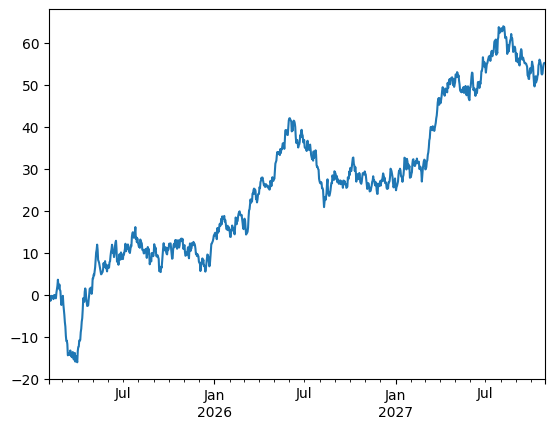

In [369]:
ts.cumsum().plot();

In [370]:
carsales = {"sales": np.random.randint(10000, 100000, size=10),
            "sales_date": pd.date_range("1/1/2024", periods=10)}

df = pd.DataFrame(carsales)
df

,sales,sales_date
0,61734,2024-01-01
1,86581,2024-01-02
2,64668,2024-01-03
3,19799,2024-01-04
4,32273,2024-01-05
5,86439,2024-01-06
6,31337,2024-01-07
7,97134,2024-01-08
8,35837,2024-01-09
9,52517,2024-01-10


In [371]:
df["sales"] = df["sales"] // 10


In [372]:
df.head(3)

,sales,sales_date
0,6173,2024-01-01
1,8658,2024-01-02
2,6466,2024-01-03


In [373]:
df["total_sales"] = df["sales"].cumsum()

In [374]:
df.head(3)

,sales,sales_date,total_sales
0,6173,2024-01-01,6173
1,8658,2024-01-02,14831
2,6466,2024-01-03,21297


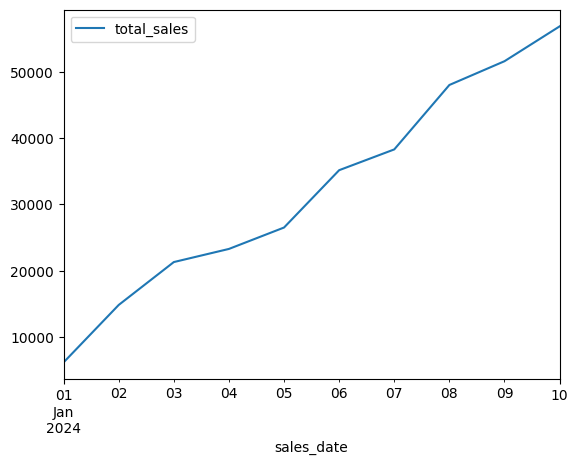

In [375]:
df.plot(x="sales_date", y="total_sales");

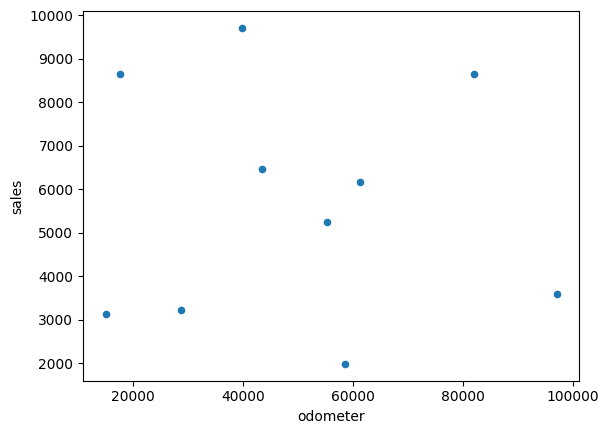

In [381]:
df["odometer"] = np.random.randint(10000, 100000, size=10)
df.plot(x="odometer", y="sales", kind="scatter");

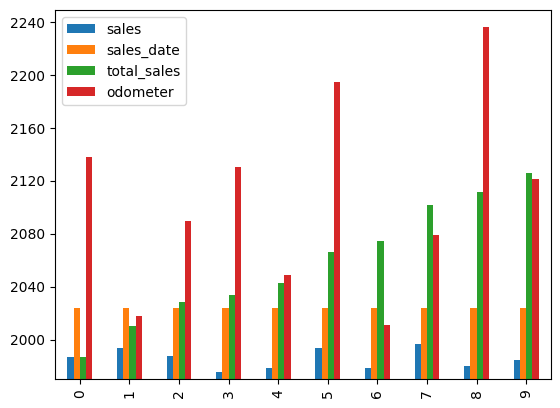

In [382]:
df.plot.bar();

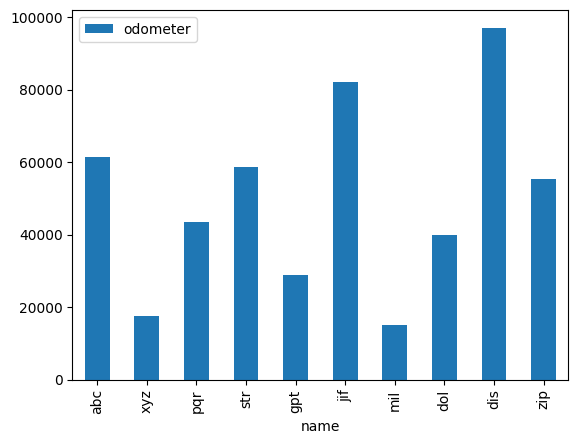

In [383]:
df["name"] = ['abc', 'xyz', 'pqr', 'str', 'gpt', 'jif', 'mil', 'dol', 'dis', 'zip']
df.plot(x="name",
        y="odometer",
        kind="bar");

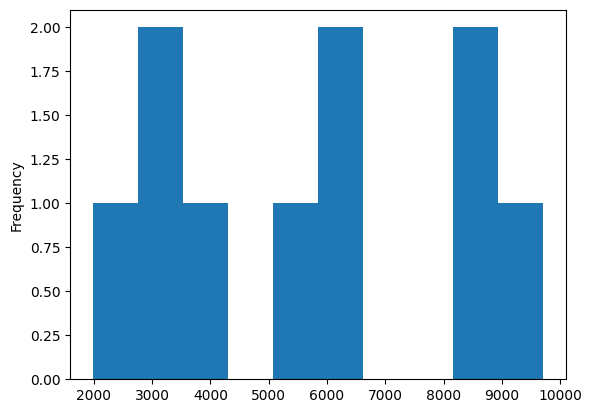

In [384]:
df["sales"].plot.hist(bins=10);

### EDA